# Spherical Anomaly Signature

In [37]:
import sys, os, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

# ── locate solver root relative to this notebook ────────────────────────────────
MASTER_PATH = Path(r"..\elfe3D_GPR").resolve()

# inputs
from elfe3d_gpr.inputs.survey import GPRSurvey
from elfe3d_gpr.inputs.anomalies import SphereAnomaly

# runner
from elfe3d_gpr.runner import ProjectPaths, run_tetgen, run_solver

# outputs
from elfe3d_gpr.outputs.fieldreader import AnalyticalLoader, ElfeLoader, CSVFieldLoader, GPRDataset
from elfe3d_gpr.outputs.postprocess import field_error, field_simple_error, error_stats
from elfe3d_gpr.outputs.visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot,
                          ReceiverLineCombined, ErrorHistogramPlot, 
                          ReceiverLineSimpleErrorPlot, SimpleErrorHistogramPlot)

# ── set once per machine ───────────────────────────────────────────────────
paths = ProjectPaths(
    master_dir = MASTER_PATH,
    exec_rel   = '',
    use_wsl    = True,   # False if running the solver directly inside WSL
)

print('Solver root:', MASTER_PATH)
print('Executable:', paths.exec_path())


Solver root: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR
Executable: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\elfe3d_gpr


## Half-Space Solution

In [38]:
output_dir = Path(paths.master_dir) / Path("out_homogeneous_earth")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_hs = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Half-Space',
    num_endfire = 48,
).endfire()

print(f'r : {ef_hs.r.min():.3f} - {ef_hs.r.max():.3f} m   ({len(ef_hs.r)} receivers)')

reading: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_homogeneous_earth\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


## Sphere in Half-Space Solution

In [39]:
output_dir = Path(paths.master_dir) / Path("out_anomaly_sphere_hs")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_s_hs = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Sphere in Half-Space',
    num_endfire = 48,
).endfire()

print(f'r : {ef_s_hs.r.min():.3f} - {ef_s_hs.r.max():.3f} m   ({len(ef_s_hs.r)} receivers)')

reading: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_anomaly_sphere_hs\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


In [40]:
# Difference: Sphere in Half-Space - Half-Space (Sphere Signature)
diff_hs_amp = field_simple_error(ef_hs, ef_s_hs, 0)
diff_hs_phase = field_simple_error(ef_hs, ef_s_hs, 1)
diff_hs_real = field_simple_error(ef_hs, ef_s_hs, 2)
diff_hs_imag = field_simple_error(ef_hs, ef_s_hs, 3)

print("Half-Space Sphere Signature:")
print(f"  Amplitude diff: mean={np.nanmean(diff_hs_amp):.4e}, max={np.nanmax(diff_hs_amp):.4e}")
print(f"  Phase diff:     mean={np.nanmean(diff_hs_phase):.4e}, max={np.nanmax(diff_hs_phase):.4e}")
print(f"  Real diff:      mean={np.nanmean(diff_hs_real):.4e}, max={np.nanmax(diff_hs_real):.4e}")
print(f"  Imag diff:      mean={np.nanmean(diff_hs_imag):.4e}, max={np.nanmax(diff_hs_imag):.4e}")

Half-Space Sphere Signature:
  Amplitude diff: mean=1.0702e+01, max=1.6325e+02
  Phase diff:     mean=-9.6802e-03, max=1.9181e-03
  Real diff:      mean=3.9731e+00, max=7.8832e+00
  Imag diff:      mean=9.4001e+00, max=1.6317e+02


## Two-Layered Earth Solution

In [41]:
output_dir = Path(paths.master_dir) / Path("out_two_layered_earth")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_tl = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Two-Layered Earth',
    num_endfire = 48,
).endfire()

print(f'r : {ef_tl.r.min():.3f} - {ef_tl.r.max():.3f} m   ({len(ef_tl.r)} receivers)')

reading: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_two_layered_earth\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


## Sphere in Two-Layered Earth Solution

In [42]:
output_dir = Path(paths.master_dir) / Path("out_anomaly_sphere")
result_txt = output_dir / Path('electric_fields_receiver_line.txt')
print('reading:', result_txt)

ef_s_tl = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR Sphere in Two-Layered Earth',
    num_endfire = 48,
).endfire()

print(f'r : {ef_s_tl.r.min():.3f} - {ef_s_tl.r.max():.3f} m   ({len(ef_s_tl.r)} receivers)')

reading: F:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_anomaly_sphere\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


In [43]:
# Difference: Sphere in Two-Layered - Two-Layered (Sphere Signature)
diff_tl_amp = field_simple_error(ef_tl, ef_s_tl, 0)
diff_tl_phase = field_simple_error(ef_tl, ef_s_tl, 1)
diff_tl_real = field_simple_error(ef_tl, ef_s_tl, 2)
diff_tl_imag = field_simple_error(ef_tl, ef_s_tl, 3)

print("Two-Layered Sphere Signature:")
print(f"  Amplitude diff: mean={np.nanmean(diff_tl_amp):.4e}, max={np.nanmax(diff_tl_amp):.4e}")
print(f"  Phase diff:     mean={np.nanmean(diff_tl_phase):.4e}, max={np.nanmax(diff_tl_phase):.4e}")
print(f"  Real diff:      mean={np.nanmean(diff_tl_real):.4e}, max={np.nanmax(diff_tl_real):.4e}")
print(f"  Imag diff:      mean={np.nanmean(diff_tl_imag):.4e}, max={np.nanmax(diff_tl_imag):.4e}")

Two-Layered Sphere Signature:
  Amplitude diff: mean=1.0311e+01, max=7.3625e+01
  Phase diff:     mean=-1.0809e-01, max=1.1384e-01
  Real diff:      mean=3.9888e+00, max=5.4353e+00
  Imag diff:      mean=9.3701e+00, max=7.3534e+01


## Semi-Analytical Sphere Solution

In [44]:
ANALYTICAL_DIR = r'..\data\data_semi_analytical'    # Directory for where to find the analytical reference data.

# Loading the analytical equivalent to the simulation.
analytical = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_sphere_total_4_100MHz.csv'),
    label='analytical',
).endfire() 

## Comparison

In [45]:
# Normalize all datasets to a common max across mie, ef_s_hs, ef_hs
def normalize_with_global(ds: GPRDataset, global_max: float, suffix: str = "(norm_all)") -> GPRDataset:
    if global_max == 0 or np.isnan(global_max):
        return ds
    return GPRDataset(
        amp=ds.amp / global_max,
        phase=ds.phase,
        real=ds.real / global_max,
        imag=ds.imag / global_max,
        orientation=ds.orientation,
        r=ds.r,
        label=f"{ds.label} {suffix}"
    )

# build mie dataset from analytical (keep as before)
analytical_real = analytical.real
analytical_imag = analytical.imag
analytical_phase = np.arctan2(analytical.imag, analytical_real)
mie = GPRDataset(
    amp=analytical.amp,
    phase=analytical_phase,
    real=analytical_real,
    imag=analytical_imag,
    orientation=analytical.orientation,
    r=analytical.r,
    label=analytical.label
)

# compute global max across amp, real, imag of the three datasets
all_vals = np.concatenate([
    np.abs(mie.amp), np.abs(mie.real), np.abs(mie.imag),
    np.abs(ef_s_hs.amp), np.abs(ef_s_hs.real), np.abs(ef_s_hs.imag),
    np.abs(ef_hs.amp), np.abs(ef_hs.real), np.abs(ef_hs.imag),
])
global_max = np.nanmax(all_vals)

# normalize all three with the same global_max
mie_norm = normalize_with_global(mie, global_max)
ef_s_hs_norm = normalize_with_global(ef_s_hs, global_max)
ef_hs_norm = normalize_with_global(ef_hs, global_max)

print("Normalized datasets (common max):")
print(f"  global max used: {global_max:.6e}")
print(f"  mie max amp: {mie_norm.amp.max():.4f}")
print(f"  elfe3D sphere (hs) max amp: {ef_s_hs_norm.amp.max():.4f}")
print(f"  elfe3D half-space max amp: {ef_hs_norm.amp.max():.4f}")

Normalized datasets (common max):
  global max used: 1.008383e+04
  mie max amp: 1.0000
  elfe3D sphere (hs) max amp: 0.9756
  elfe3D half-space max amp: 0.9594


## Overlapped Subplots

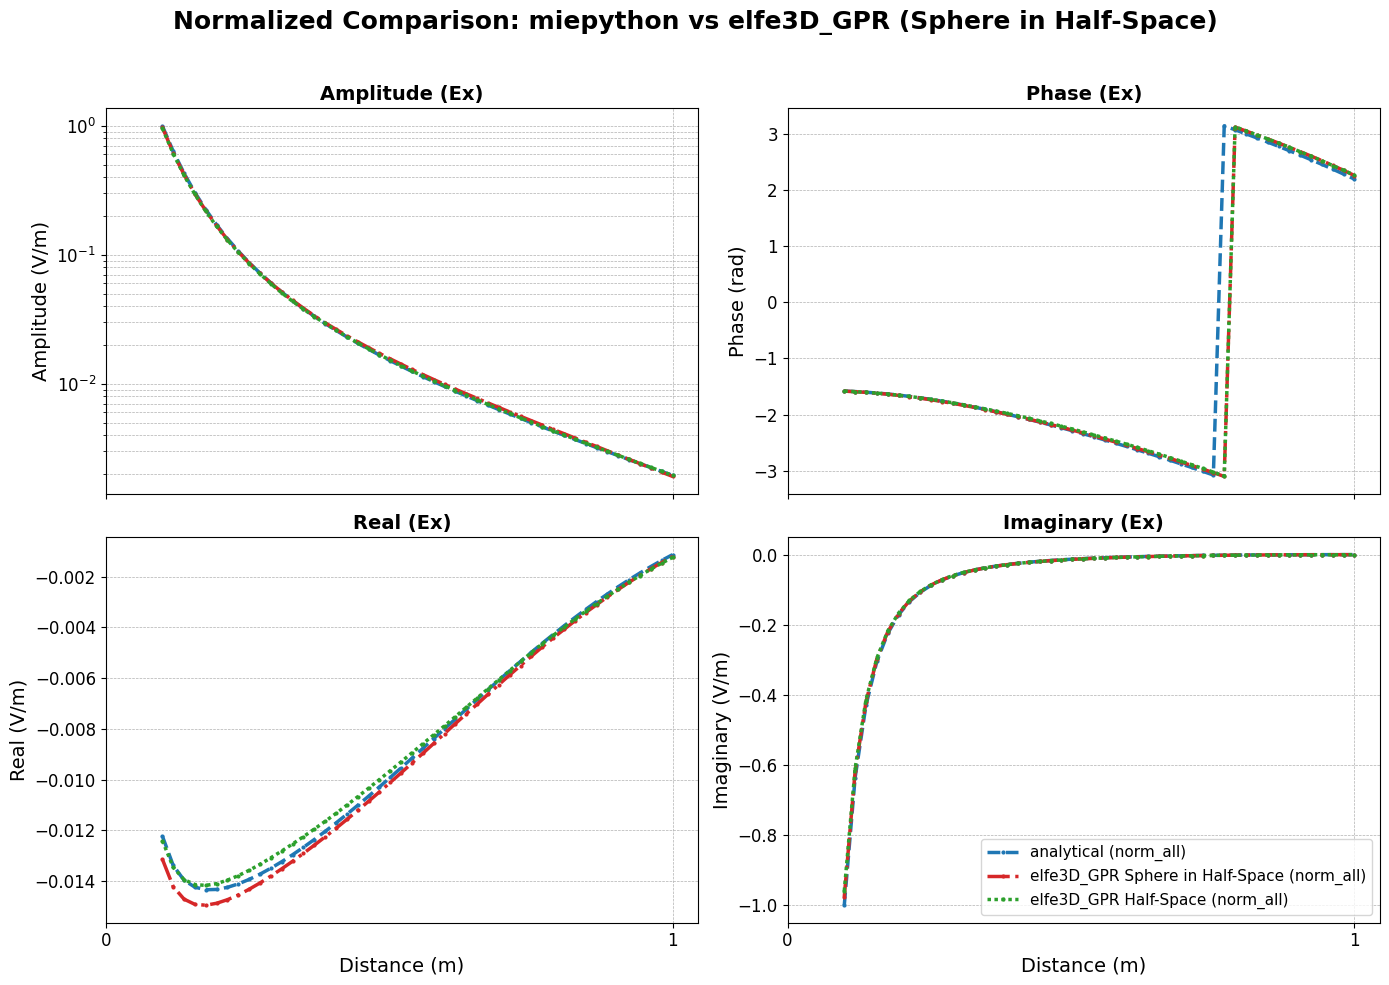

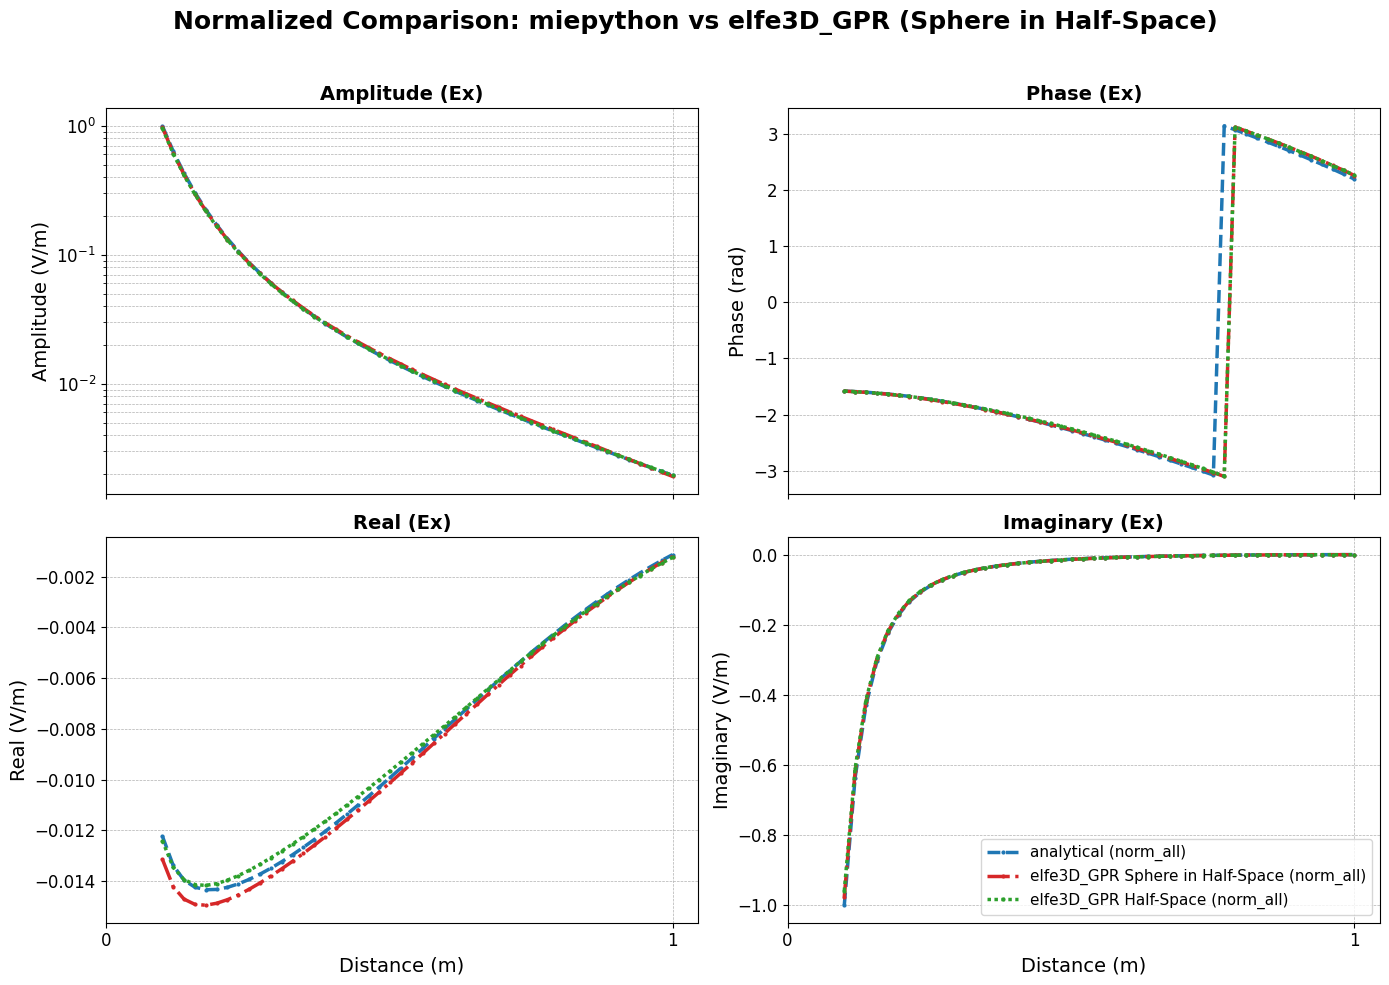

In [46]:
# Plot normalized comparison: miepython vs elfe3D sphere vs half-space background
ReceiverLinePlot(
    datasets=[mie_norm, ef_s_hs_norm, ef_hs_norm],
    base_lw=2.5,
    font={"suptitle": 18, "label": 14, "tick": 12, "legend": 11},
    figsize=(14, 10)
).plot(suptitle="Normalized Comparison: miepython vs elfe3D_GPR (Sphere in Half-Space)")

## Difference: elfe3D sphere vs miepython

In [47]:
# Compute error between elfe3D sphere solution and miepython analytical solution
# Note: may need to interpolate if receiver grids differ
print("elfe3D_GPR Sphere vs Semi-Analytical:")
print(f"  miepython r range: {mie.r.min():.3f} - {mie.r.max():.3f} m")
print(f"  elfe3D sphere r range: {ef_s_hs.r.min():.3f} - {ef_s_hs.r.max():.3f} m")

# Use field_simple_error to compute absolute difference
diff_mie_amp = field_simple_error(mie, ef_s_hs, 0)
diff_mie_phase = field_simple_error(mie, ef_s_hs, 1)
diff_mie_real = field_simple_error(mie, ef_s_hs, 2)
diff_mie_imag = field_simple_error(mie, ef_s_hs, 3)

print(f"\n  Amplitude diff: mean={np.nanmean(diff_mie_amp):.4e}, max={np.nanmax(diff_mie_amp):.4e}")
print(f"  Phase diff:     mean={np.nanmean(diff_mie_phase):.4e}, max={np.nanmax(diff_mie_phase):.4e}")
print(f"  Real diff:      mean={np.nanmean(diff_mie_real):.4e}, max={np.nanmax(diff_mie_real):.4e}")
print(f"  Imag diff:      mean={np.nanmean(diff_mie_imag):.4e}, max={np.nanmax(diff_mie_imag):.4e}")

elfe3D_GPR Sphere vs Semi-Analytical:
  miepython r range: 0.100 - 1.000 m
  elfe3D sphere r range: 0.100 - 1.000 m

  Amplitude diff: mean=1.6823e+01, max=2.4601e+02
  Phase diff:     mean=-1.0865e-01, max=6.6063e-02
  Real diff:      mean=2.6338e+00, max=9.1922e+00
  Imag diff:      mean=1.7138e+01, max=2.4615e+02


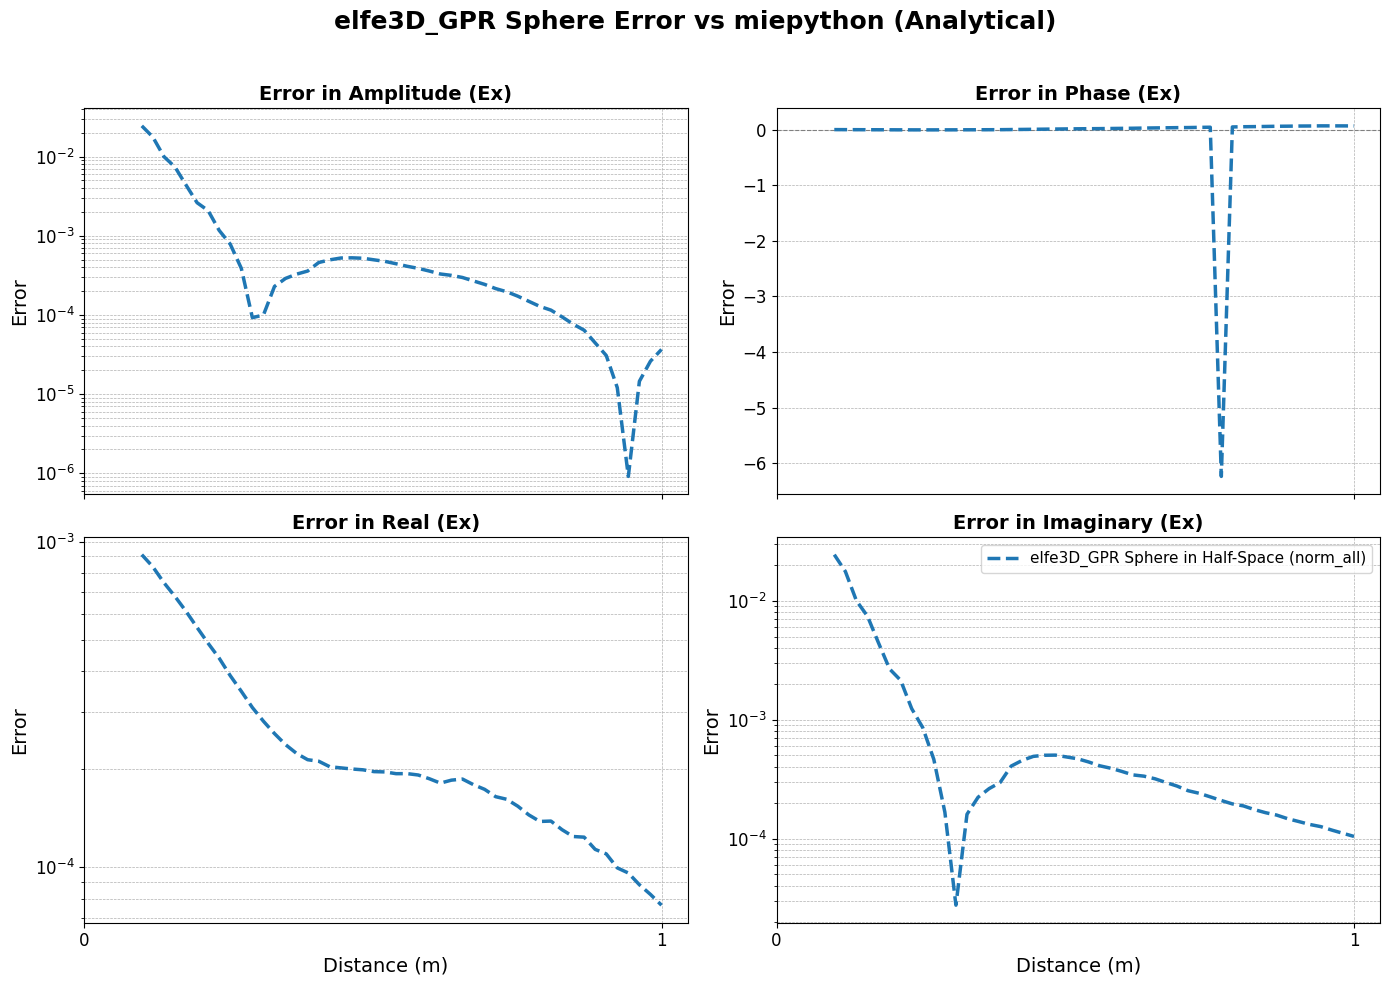

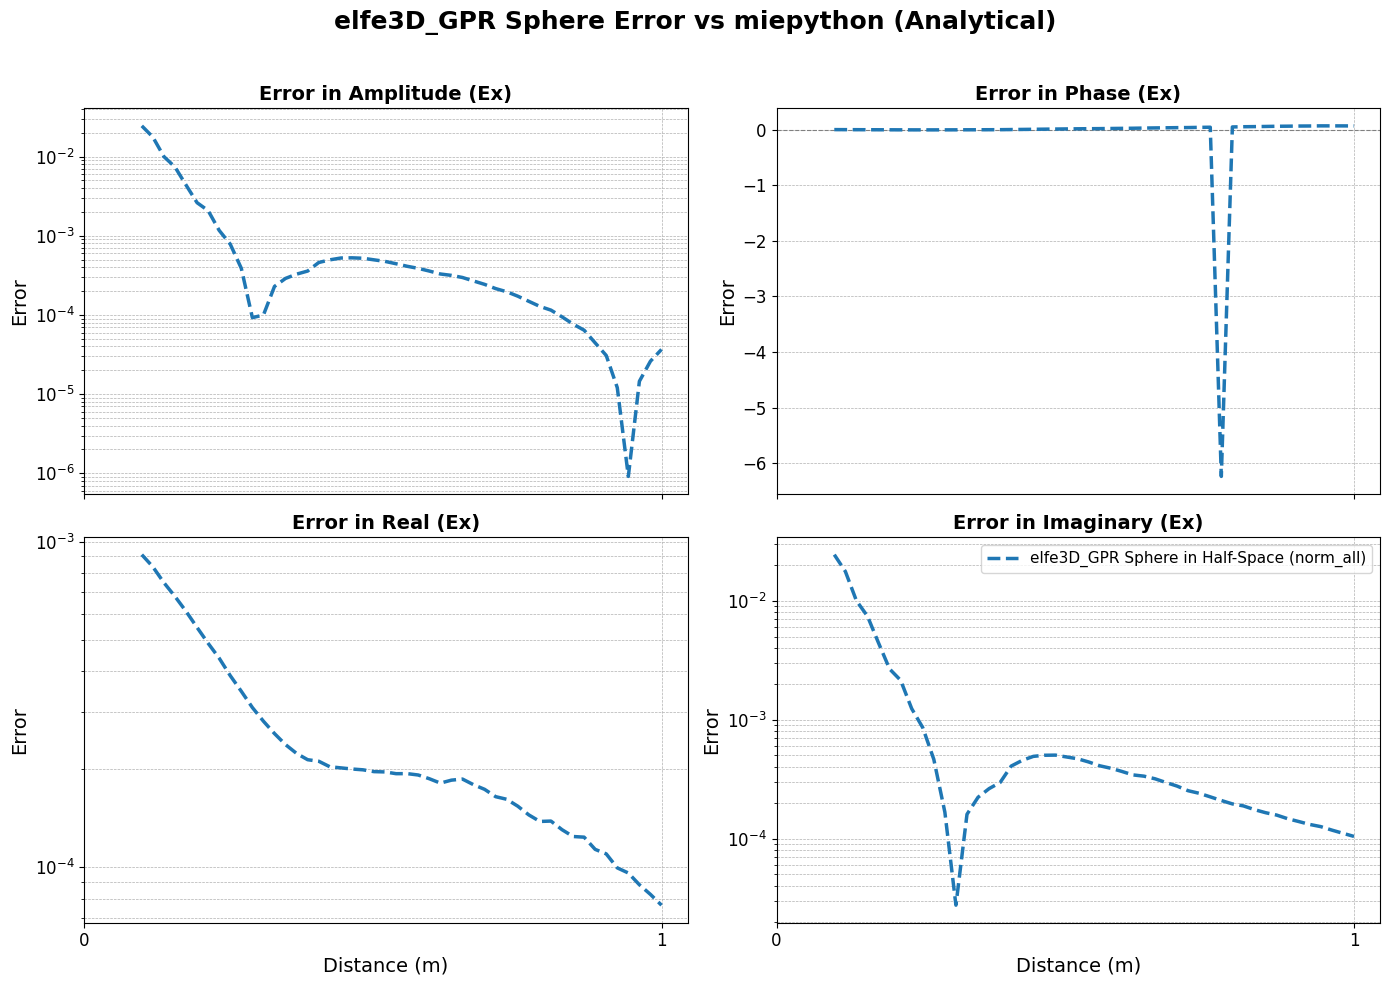

In [48]:
# Plot error: elfe3D sphere vs miepython
ReceiverLineSimpleErrorPlot(
    datasets=[ef_s_hs_norm],
    reference=mie_norm,
    base_lw=2.5,
    font={"suptitle": 18, "label": 14, "tick": 12, "legend": 11},
    figsize=(14, 10)
).plot(suptitle="elfe3D_GPR Sphere Error vs miepython (Analytical)")

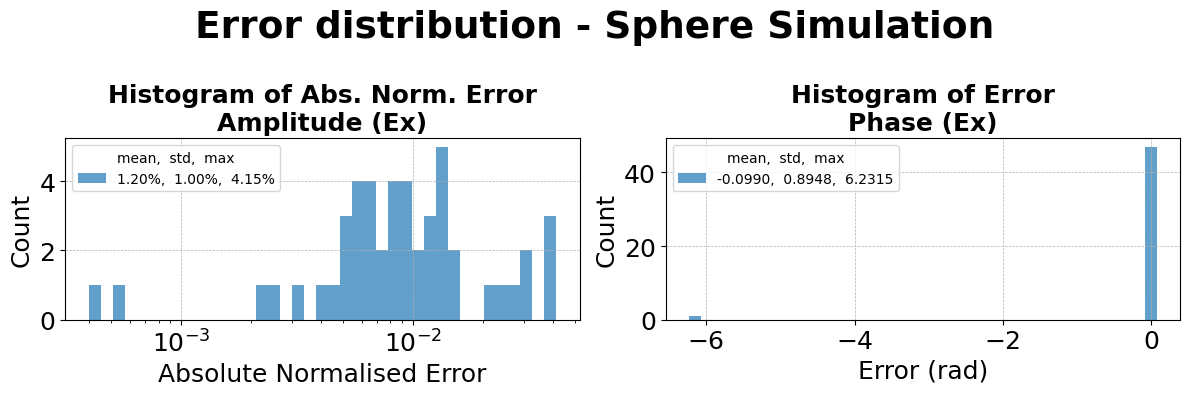

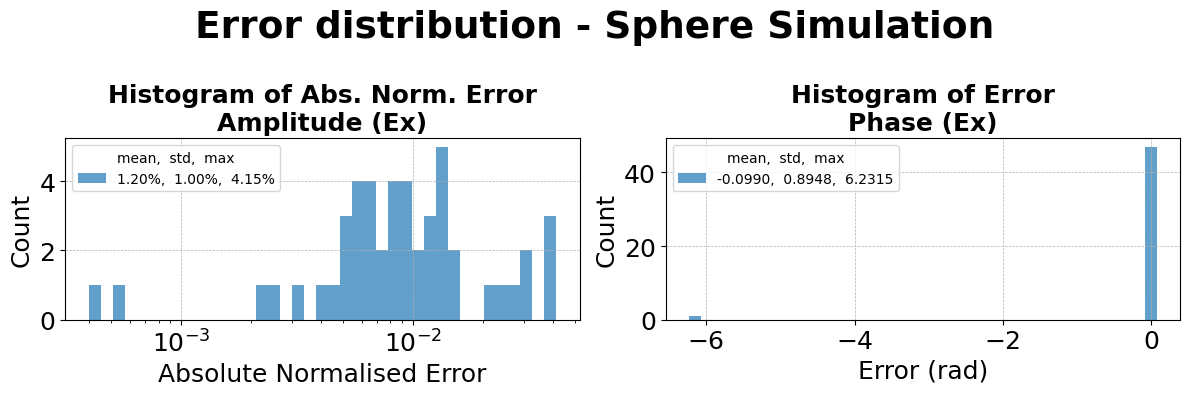

In [50]:
ErrorHistogramPlot([ef_hs_norm], reference=mie_norm).plot(suptitle='Error distribution - Sphere Simulation')